# Approach 2 — TF-IDF + Naive Bayes (baseline)

**Why this model is in the study.** A classic, fast, non-sequential text-classification baseline (Wang & Manning, 2012). It learns very differently from logistic regression (Approach 1): it is generative and models word counts per class, so comparing the two shows how much the choice of simple model matters. Its stated limitations in our plan are (a) it treats words as independent and (b) it tends to favour large classes. **This notebook tests limitation (b) directly** because the EDA showed extreme imbalance (`Kimataifa` 54, `Burudani` 17 articles).

**Protocol (keep identical across the group so results are comparable)**
- Cleaning: repair the 255 malformed `michezo` list-literal records, drop near-empty documents (<3 words)
- The group's **shared split** (`split_ids.csv`, created in the Approach 1 notebook: stratified 80/20, `random_state=42`) — the validation part is touched **once**, at the end
- All model selection uses 5-fold stratified CV on the training part only
- Primary metric **macro-F1** (accuracy is dominated by the 3 large classes); per-class F1 always reported

> Setup: put the Zindi `Train.csv` in `data/` (not committed to GitHub — Zindi data policy). Needs only `pandas, numpy, scikit-learn, matplotlib`. Runs top to bottom in ~2–3 min on Colab.

In [1]:
import os, re, ast, glob, warnings, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)
warnings.filterwarnings("ignore")

SEED = 42                          # CV folds + oversampling; same value as the shared split
os.makedirs("figures", exist_ok=True); os.makedirs("models", exist_ok=True); os.makedirs("results", exist_ok=True)

def find_file(pattern):
    hits = [p for p in glob.glob("**/*.csv", recursive=True) if pattern in os.path.basename(p).lower()
            and not any(x in os.path.basename(p).lower() for x in ("split", "ids", "errors", "experiments", "preds"))]            if pattern != "split_ids" else glob.glob("**/split_ids.csv", recursive=True)
    assert hits, f"Could not find {pattern}: put the Zindi Train.csv (and the shared split_ids.csv) next to the notebook or in ./data/"
    return hits[0]
raw = pd.read_csv(find_file("train"))
print(raw.shape, raw.columns.tolist())

(5151, 3) ['id', 'content', 'category']


## 1. Cleaning (motivated by the EDA)

In [2]:
LIST_RE = re.compile(r"^\s*\[.*\]\s*$", re.S)
URL_RE  = re.compile(r"https?://\S+|www\.\S+")

def repair_list_literal(t):
    """255 michezo records are stringified Python lists: parse and re-join into prose."""
    t = str(t)
    if LIST_RE.match(t):
        try:
            v = ast.literal_eval(t)
            if isinstance(v, (list, tuple)):
                return " ".join(str(x).strip() for x in v)
        except Exception:
            pass
    return t

def clean(t):
    t = URL_RE.sub(" ", repair_list_literal(t).lower())
    return re.sub(r"^[\s\.]+", "", t)          # stray leading '.' seen in many records

df = raw.copy()
df["is_list_literal"] = df["content"].astype(str).apply(lambda t: bool(LIST_RE.match(t)))
df["raw"]   = df["content"].astype(str)
df["clean"] = df["content"].apply(clean)
n0 = len(df)
df = df[df["clean"].str.split().str.len() >= 3].reset_index(drop=True)
print(f"list-literal records repaired: {int(raw['content'].astype(str).apply(lambda t: bool(LIST_RE.match(t))).sum())}")
print(f"near-empty documents dropped : {n0-len(df)}")
print(df["category"].value_counts())

list-literal records repaired: 255
near-empty documents dropped : 3
category
Kitaifa      2000
michezo      1719
Biashara     1359
Kimataifa      54
Burudani       16
Name: count, dtype: int64


## 2. Split protocol — use the group's shared `split_ids.csv`

In [3]:
# split_ids.csv (columns: id, split in {train, val}) is created by the Approach 1 notebook and shared by all five models.
split = pd.read_csv(find_file("split_ids"))
assert set(split["id"]) == set(df["id"]), "split_ids.csv does not match the cleaned data - re-run the shared cleaning first"
df = df.merge(split, on="id")
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
LABELS = sorted(df["category"].unique())
print("train:", len(train_df), "| validation:", len(val_df))
print(pd.crosstab(df["category"], df["split"]))
skf = StratifiedKFold(5, shuffle=True, random_state=SEED)

train: 4118 | validation: 1030
split      train  val
category             
Biashara    1087  272
Burudani      13    3
Kimataifa     43   11
Kitaifa     1600  400
michezo     1375  344


**Caveat to keep in mind for every number below:** the validation part contains only **3 `Burudani`** and **11 `Kimataifa`** articles, so validation per-class scores for those two classes are extremely noisy (one article changes F1 by tens of points). For the minority classes we therefore lean on **pooled out-of-fold CV predictions** over the training part (13 `Burudani`, 43 `Kimataifa`), and report validation results alongside, not instead.

## 3. Experiment framework
Every experiment is scored the same way: 5-fold stratified CV on the training part, **any resampling happens inside the training fold only** (so no leakage into validation). We log mean±std macro-F1 across folds, accuracy, and pooled out-of-fold per-class F1.

In [4]:
def oversample(X, y, target, seed=SEED):
    """Random oversampling by duplication: every class with < target docs is upsampled to target."""
    rng = np.random.RandomState(seed); Xs, ys = [X], [y]
    for c in y.unique():
        idx = np.where(y.values == c)[0]
        if len(idx) < target:
            add = rng.choice(idx, target - len(idx), replace=True)
            Xs.append(X.iloc[add]); ys.append(y.iloc[add])
    return pd.concat(Xs), pd.concat(ys)

RESULTS, OOF = [], {}
def run_experiment(tag, note, vec, clf, col="clean", target=None, keep_oof=False):
    fold_f1, oof_pred, oof_proba = [], pd.Series(index=train_df.index, dtype=object), None
    for a, b in skf.split(train_df[col], train_df.category):
        Xa, ya = train_df[col].iloc[a], train_df.category.iloc[a]
        if target: Xa, ya = oversample(Xa, ya, target)
        p = Pipeline([("v", clone(vec)), ("c", clone(clf))]).fit(Xa, ya)
        pred = p.predict(train_df[col].iloc[b]); oof_pred.iloc[b] = pred
        if keep_oof:
            if oof_proba is None: oof_proba = np.zeros((len(train_df), len(p.classes_)))
            oof_proba[b] = p.predict_proba(train_df[col].iloc[b])
        fold_f1.append(f1_score(train_df.category.iloc[b], pred, average="macro"))
    per = f1_score(train_df.category, oof_pred, average=None, labels=LABELS)
    row = {"exp": tag, "what changed / why": note, "macro-F1 (mean)": np.mean(fold_f1), "std": np.std(fold_f1),
           "accuracy": accuracy_score(train_df.category, oof_pred), **{f"F1 {l}": f for l, f in zip(LABELS, per)}}
    RESULTS.append(row)
    if keep_oof: OOF[tag] = (oof_pred, oof_proba)
    print(f"{tag:6s} macro-F1={row['macro-F1 (mean)']:.3f}±{row['std']:.3f}  acc={row['accuracy']:.3f}  | {note}")

### 3.1 Baseline and preprocessing (does cleaning / TF-IDF weighting matter?)

In [5]:
TF = lambda **k: TfidfVectorizer(**k)
run_experiment("E1", "naive baseline: raw text (no repair), TF-IDF unigrams, MultinomialNB alpha=1", TF(), MultinomialNB(), col="raw")
run_experiment("E2", "+ repair list-literals, lowercase, strip URLs", TF(), MultinomialNB())
run_experiment("E3", "+ sublinear TF (log-scaled counts)", TF(sublinear_tf=True), MultinomialNB())

E1     macro-F1=0.390±0.006  acc=0.719  | naive baseline: raw text (no repair), TF-IDF unigrams, MultinomialNB alpha=1


E2     macro-F1=0.390±0.006  acc=0.719  | + repair list-literals, lowercase, strip URLs


E3     macro-F1=0.367±0.003  acc=0.698  | + sublinear TF (log-scaled counts)


**Reading E1→E3.** Cleaning barely moves macro-F1 for a bag-of-words model (E1≈E2): the malformed records still contain the right words, and word-level features simply ignore the bracket/quote noise. So the list-literal repair matters for the sequence models (which see raw token order) more than for this baseline — worth stating in the report rather than assuming it helps everywhere. Sublinear TF alone *hurt* (E3), which was a first hint that the real problem is elsewhere: smoothing.

### 3.2 Smoothing (alpha) — the biggest lever for MultinomialNB on TF-IDF

In [6]:
for a in [0.3, 0.1, 0.03, 0.01]:
    run_experiment("E4", f"MultinomialNB alpha={a} (sublinear TF-IDF)", TF(sublinear_tf=True), MultinomialNB(alpha=a))

E4     macro-F1=0.459±0.006  acc=0.783  | MultinomialNB alpha=0.3 (sublinear TF-IDF)


E4     macro-F1=0.506±0.004  acc=0.839  | MultinomialNB alpha=0.1 (sublinear TF-IDF)


E4     macro-F1=0.537±0.057  acc=0.846  | MultinomialNB alpha=0.03 (sublinear TF-IDF)


E4     macro-F1=0.535±0.058  acc=0.842  | MultinomialNB alpha=0.01 (sublinear TF-IDF)


**Reading E4.** Macro-F1 jumps from ~0.37 at alpha=1 to ~0.54 at alpha≤0.03. TF-IDF rows are L2-normalised, so each feature value is tiny; a Laplace alpha of 1 then dwarfs the real evidence and pulls every class toward the prior. Lower alpha lets the words speak. Note that accuracy also rises (0.70→0.85), but the two minority classes still score at most 0.14 F1 (`Burudani`, i.e. a handful of articles).

### 3.3 Richer features (does word order / morphology help?)

In [7]:
run_experiment("E5", "word uni+bigrams (min_df=2), MNB alpha=0.1", TF(sublinear_tf=True, ngram_range=(1,2), min_df=2), MultinomialNB(alpha=0.1))
run_experiment("E6", "character n-grams 3-5 (targets Swahili morphology), MNB alpha=0.1",
               TF(sublinear_tf=True, analyzer="char_wb", ngram_range=(3,5), min_df=3, max_features=300000), MultinomialNB(alpha=0.1))

E5     macro-F1=0.510±0.005  acc=0.845  | word uni+bigrams (min_df=2), MNB alpha=0.1


E6     macro-F1=0.502±0.007  acc=0.831  | character n-grams 3-5 (targets Swahili morphology), MNB alpha=0.1


**Reading E5–E6.** Neither bigrams nor character n-grams beat plain unigrams (at alpha=0.1: unigrams 0.506, bigrams 0.510, char n-grams 0.502 — all within noise). For this task the topic signal is already carried by individual (sub)words, consistent with the EDA finding that categories are lexically separable. Character n-grams did not fix the rare-word/morphology problem for NB, so the gain, if any, from subword modelling has to come from the neural models, not from feature engineering here.

### 3.4 Attacking the class-imbalance limitation directly

In [8]:
run_experiment("E7", "MNB alpha=0.1, fit_prior=False (uniform class prior)", TF(sublinear_tf=True), MultinomialNB(alpha=0.1, fit_prior=False))
for a in [0.03, 0.3]:
    run_experiment("E8", f"ComplementNB alpha={a} (Rennie et al., 2003: built for skewed text data)", TF(sublinear_tf=True), ComplementNB(alpha=a))

E7     macro-F1=0.538±0.055  acc=0.847  | MNB alpha=0.1, fit_prior=False (uniform class prior)


E8     macro-F1=0.568±0.064  acc=0.854  | ComplementNB alpha=0.03 (Rennie et al., 2003: built for skewed text data)


E8     macro-F1=0.531±0.055  acc=0.842  | ComplementNB alpha=0.3 (Rennie et al., 2003: built for skewed text data)


**Reading E7–E8.** Removing the prior gives MNB a small gain at alpha=0.1 (0.506 → 0.538), but only because `Burudani` moves from 0 to 0.14 F1 (one article in some folds), and plain alpha=0.03 already reaches 0.537 — so the prior is not the main culprit; the likelihood is dominated by the big classes' vocabulary. **ComplementNB** (E8, alpha=0.03) is the first change that lifts both minority classes without touching the data (`Burudani` 0.27, `Kimataifa` 0.04 pooled) and reaches macro-F1 0.568 vs 0.537 for the best MNB. Its fold-to-fold std is large (~0.06) because whether even one `Burudani`/`Kimataifa` article is caught changes a fold's macro-F1 a lot.

### 3.5 Class-balancing by oversampling (inside the training fold only)

In [9]:
for t in [200, 500, 1000]:
    run_experiment("E9", f"ComplementNB alpha=0.03 + oversample minority classes to {t} docs", TF(sublinear_tf=True), ComplementNB(alpha=0.03), target=t, keep_oof=(t==500))
run_experiment("E10", "E9(500) + word uni+bigrams (min_df=2)", TF(sublinear_tf=True, ngram_range=(1,2), min_df=2), ComplementNB(alpha=0.03), target=500)
run_experiment("E11", "E9(500) with alpha=0.01", TF(sublinear_tf=True), ComplementNB(alpha=0.01), target=500)

E9     macro-F1=0.669±0.076  acc=0.852  | ComplementNB alpha=0.03 + oversample minority classes to 200 docs


E9     macro-F1=0.676±0.079  acc=0.849  | ComplementNB alpha=0.03 + oversample minority classes to 500 docs


E9     macro-F1=0.664±0.069  acc=0.849  | ComplementNB alpha=0.03 + oversample minority classes to 1000 docs


E10    macro-F1=0.663±0.076  acc=0.852  | E9(500) + word uni+bigrams (min_df=2)


E11    macro-F1=0.647±0.075  acc=0.841  | E9(500) with alpha=0.01


**Reading E9–E11.** Oversampling on top of ComplementNB is the largest single improvement (macro-F1 0.57 → ~0.67), driven by minority-class recall (`Burudani` 0.27 → 0.50, `Kimataifa` 0.04 → 0.36 at 500). The 200, 500 and 1000 targets give 0.669, 0.676 and 0.664, indistinguishable to the naked eye of the fold-to-fold std (~0.07) which is why we choose to go with **500**: we don't want to have to deal with the risk of having the same 13 articles duplicated too many times. Bigrams (E10, 0.663) and a smaller alpha (E11, 0.647) do not help. A methodological note: When switching to the group's common split file (same rows, different row order, hence different fold assignment) E9(500) increased from 0.656 to 0.676, so differences of ~0.02 between configurations should not be taken as real. Final configured model: TF-IDF (unigrams, sublinear) + ComplementNB(alpha=0.03) + oversample to 500.

In [10]:
res = pd.DataFrame(RESULTS)
res.to_csv("results/nb_experiments.csv", index=False)
pd.set_option("display.width", 250, "display.max_colwidth", 70)
res.round(3)

,exp,what changed / why,macro-F1 (mean),std,accuracy,F1 Biashara,F1 Burudani,F1 Kimataifa,F1 Kitaifa,F1 michezo
0,E1,"naive baseline: raw text (no repair), TF-IDF unigrams, Multinomial...",0.390,0.006,0.719,0.303,0.000,0.000,0.730,0.920
1,E2,"+ repair list-literals, lowercase, strip URLs",0.390,0.006,0.719,0.303,0.000,0.000,0.730,0.920
2,E3,+ sublinear TF (log-scaled counts),0.367,0.003,0.698,0.211,0.000,0.000,0.716,0.910
3,E4,MultinomialNB alpha=0.3 (sublinear TF-IDF),0.459,0.006,0.783,0.596,0.000,0.000,0.776,0.923
4,E4,MultinomialNB alpha=0.1 (sublinear TF-IDF),0.506,0.004,0.839,0.780,0.000,0.000,0.817,0.931
5,E4,MultinomialNB alpha=0.03 (sublinear TF-IDF),0.537,0.057,0.846,0.803,0.143,0.000,0.815,0.935
6,E4,MultinomialNB alpha=0.01 (sublinear TF-IDF),0.535,0.058,0.842,0.797,0.143,0.000,0.812,0.933
7,E5,"word uni+bigrams (min_df=2), MNB alpha=0.1",0.510,0.005,0.845,0.800,0.000,0.000,0.819,0.932
8,E6,"character n-grams 3-5 (targets Swahili morphology), MNB alpha=0.1",0.502,0.007,0.831,0.793,0.000,0.000,0.805,0.915
9,E7,"MNB alpha=0.1, fit_prior=False (uniform class prior)",0.538,0.055,0.847,0.805,0.143,0.000,0.819,0.932


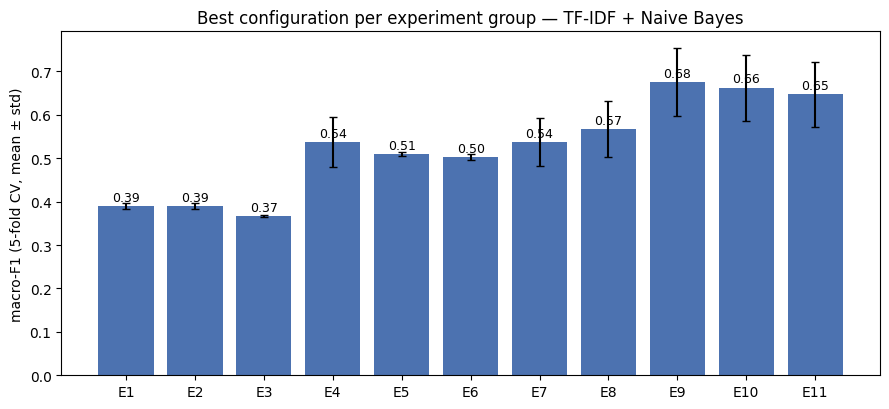

In [11]:
best = res.sort_values("macro-F1 (mean)").groupby("exp").tail(1).sort_values("exp", key=lambda s: s.str[1:].astype(int))
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(best["exp"], best["macro-F1 (mean)"], yerr=best["std"], color="#4C72B0", capsize=3)
ax.set_ylabel("macro-F1 (5-fold CV, mean ± std)"); ax.set_title("Best configuration per experiment group — TF-IDF + Naive Bayes")
for i, v in enumerate(best["macro-F1 (mean)"]): ax.text(i, v + 0.012, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout(); plt.savefig("figures/nb_experiment_progression.png", dpi=150); plt.show()

## 4. Final model — one evaluation on the untouched validation split

In [12]:
TARGET = 500
Xa, ya = oversample(train_df["clean"], train_df["category"], TARGET)
final = Pipeline([("v", TF(sublinear_tf=True)), ("c", ComplementNB(alpha=0.03))]).fit(Xa, ya)
joblib.dump(final, "models/tfidf_complementnb.joblib")

pred = final.predict(val_df["clean"])
print(classification_report(val_df["category"], pred, digits=3, zero_division=0))
print("validation macro-F1:", round(f1_score(val_df["category"], pred, average="macro"), 4),
      "| accuracy:", round(accuracy_score(val_df["category"], pred), 4))

# Predictions in a common format so a comparison notebook can score all five models identically
proba_val = final.predict_proba(val_df["clean"])
preds = pd.DataFrame({"id": val_df["id"], "true": val_df["category"], "pred": pred})
for i, c in enumerate(final.classes_): preds[f"proba_{c}"] = proba_val[:, i].round(5)
preds.to_csv("results/tfidf_naive_bayes_val_preds.csv", index=False)

              precision    recall  f1-score   support

    Biashara      0.855     0.713     0.778       272
    Burudani      0.000     0.000     0.000         3
   Kimataifa      0.500     0.182     0.267        11
     Kitaifa      0.776     0.885     0.827       400
     michezo      0.953     0.939     0.946       344

    accuracy                          0.848      1030
   macro avg      0.617     0.544     0.563      1030
weighted avg      0.851     0.848     0.845      1030

validation macro-F1: 0.5634 | accuracy: 0.8476


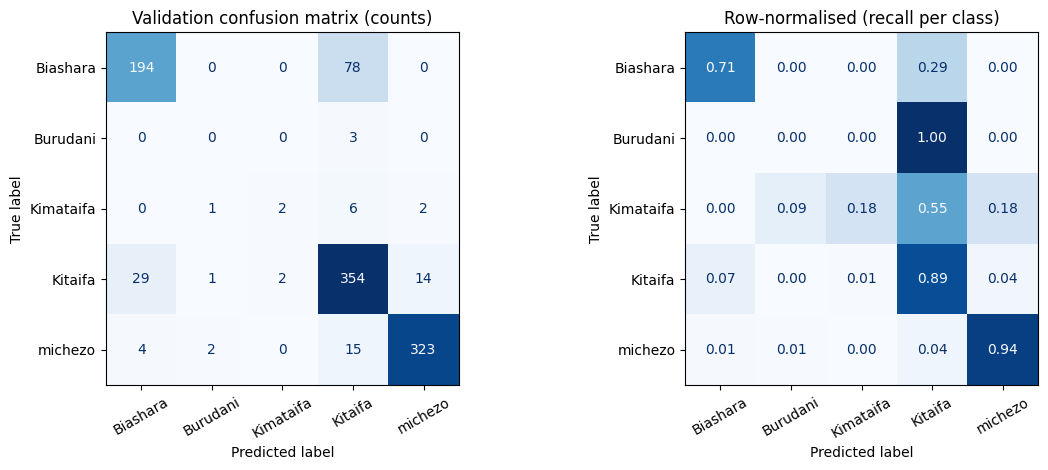

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
cm = confusion_matrix(val_df["category"], pred, labels=LABELS)
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=30)
axes[0].set_title("Validation confusion matrix (counts)")
ConfusionMatrixDisplay(cm / cm.sum(1, keepdims=True), display_labels=LABELS).plot(ax=axes[1], cmap="Blues", colorbar=False, xticks_rotation=30, values_format=".2f")
axes[1].set_title("Row-normalised (recall per class)")
plt.tight_layout(); plt.savefig("figures/nb_confusion_val.png", dpi=150); plt.show()

**Validation vs CV.** Validation macro-F1 (0.563, accuracy 0.848) is lower than CV (0.676) almost entirely because of the 3 `Burudani` articles, none of which is recovered (F1 0.00 vs 0.50 pooled) and `Kimataifa` (11 articles, F1 0.27 vs 0.36 pooled). With n=3 and n=11 this is not evidence that the model got worse — it is the size of the split. The three large classes are stable across both (Biashara ≈0.77, Kitaifa ≈0.83, michezo ≈0.95), so the validation and pooled-OOF views agree on everything except the minority classes.

### 4.1 More stable minority-class evidence: pooled out-of-fold predictions (training part)

              precision    recall  f1-score   support

    Biashara      0.845     0.700     0.766      1087
    Burudani      0.545     0.462     0.500        13
   Kimataifa      0.500     0.279     0.358        43
     Kitaifa      0.777     0.882     0.826      1600
     michezo      0.957     0.950     0.953      1375

    accuracy                          0.849      4118
   macro avg      0.725     0.654     0.681      4118
weighted avg      0.851     0.849     0.847      4118



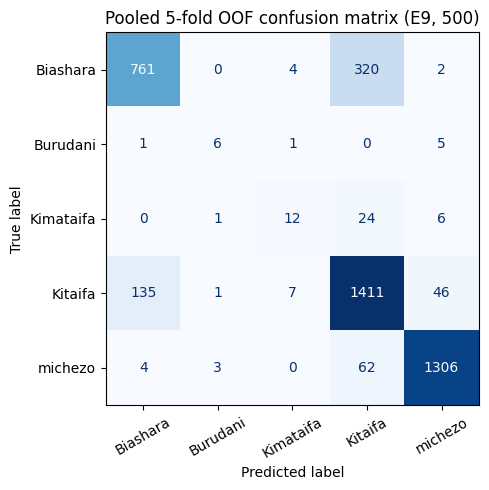

In [14]:
oof_pred, oof_proba = OOF["E9"]
print(classification_report(train_df["category"], oof_pred, digits=3, zero_division=0))
cm2 = confusion_matrix(train_df["category"], oof_pred, labels=LABELS)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm2, display_labels=LABELS).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=30)
ax.set_title("Pooled 5-fold OOF confusion matrix (E9, 500)"); plt.tight_layout()
plt.savefig("figures/nb_confusion_oof.png", dpi=150); plt.show()

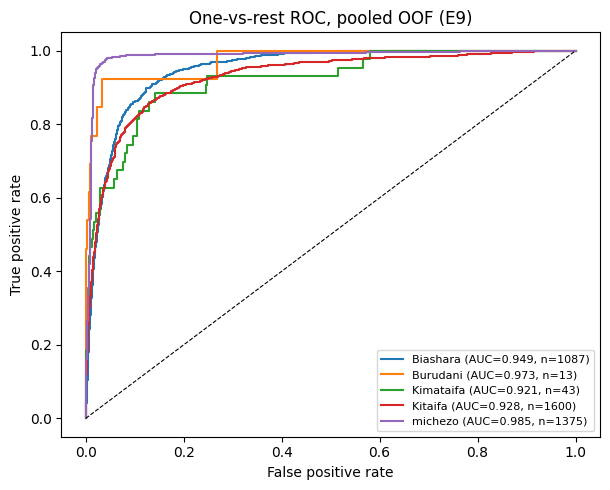

In [15]:
# One-vs-rest ROC from pooled OOF scores (rank-based, so NB's poor calibration does not matter here)
cls = list(final.classes_)
fig, ax = plt.subplots(figsize=(6.2, 5))
for i, c in enumerate(cls):
    y = (train_df["category"].values == c).astype(int)
    fpr, tpr, _ = roc_curve(y, oof_proba[:, i]); ax.plot(fpr, tpr, label=f"{c} (AUC={auc(fpr, tpr):.3f}, n={y.sum()})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8); ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("One-vs-rest ROC, pooled OOF (E9)"); ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.savefig("figures/nb_roc_oof.png", dpi=150); plt.show()

### 4.2 Learning curve — does the model need more data?

 train_articles  train_F1  val_F1  val_std
            988     0.992   0.532    0.013
           1482     0.992   0.601    0.079
           1976     0.993   0.609    0.086
           2635     0.992   0.614    0.071
           3294     0.991   0.676    0.079


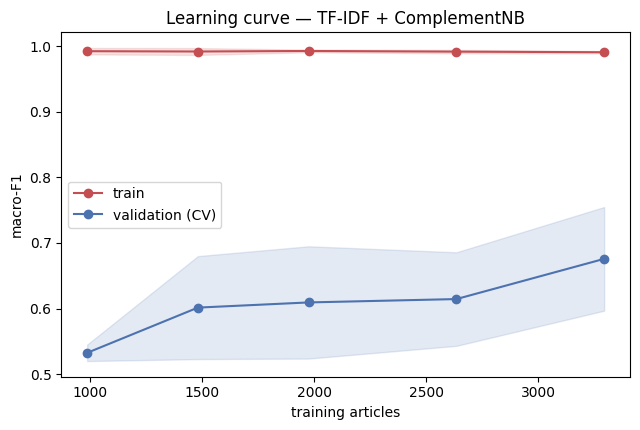

In [16]:
fracs = [0.3, 0.45, 0.6, 0.8, 1.0]; tr_s, va_s = [], []
for f in fracs:
    t_, v_ = [], []
    for a, b in skf.split(train_df["clean"], train_df.category):
        sub = train_df.iloc[a]
        if f < 1.0: sub, _ = train_test_split(sub, train_size=f, stratify=sub.category, random_state=SEED)
        Xs, ys = oversample(sub["clean"], sub["category"], TARGET)
        m = Pipeline([("v", TF(sublinear_tf=True)), ("c", ComplementNB(alpha=0.03))]).fit(Xs, ys)
        t_.append(f1_score(sub["category"], m.predict(sub["clean"]), average="macro"))
        v_.append(f1_score(train_df.category.iloc[b], m.predict(train_df["clean"].iloc[b]), average="macro"))
    tr_s.append(t_); va_s.append(v_)
n_tr = [int(f * len(train_df) * 0.8) for f in fracs]
print(pd.DataFrame({"train_articles": n_tr, "train_F1": np.mean(tr_s, 1).round(3), "val_F1": np.mean(va_s, 1).round(3), "val_std": np.std(va_s, 1).round(3)}).to_string(index=False))
fig, ax = plt.subplots(figsize=(6.5, 4.4))
for s, lab, col in [(tr_s, "train", "#C44E52"), (va_s, "validation (CV)", "#4C72B0")]:
    m, sd = np.mean(s, 1), np.std(s, 1); ax.plot(n_tr, m, "o-", label=lab, color=col); ax.fill_between(n_tr, m - sd, m + sd, alpha=0.15, color=col)
ax.set_xlabel("training articles"); ax.set_ylabel("macro-F1"); ax.set_title("Learning curve — TF-IDF + ComplementNB"); ax.legend()
plt.tight_layout(); plt.savefig("figures/nb_learning_curve.png", dpi=150); plt.show()

**Reading the learning curve.** Training macro-F1 stays near 0.99 while validation macro-F1 climbs from 0.53 to 0.68 with a wide band: a large train/validation gap, i.e. **high variance** — the model memorises its training articles (made stronger by the duplicated minority documents). Validation is still rising at the largest size, so more labelled data (above all for `Kimataifa`/`Burudani`) would help more than further tuning of a model this simple. The wide band mostly reflects minority-class luck per fold, not instability on the three large classes.

## 5. Error analysis (feeds Section 4 of the report)

In [17]:
# Data-level view (not model weights): words with the largest gap between class-mean TF-IDF and the rest, words in >=25 docs
vec = TfidfVectorizer(sublinear_tf=True, min_df=25).fit(train_df["clean"])
Xt, feats = vec.transform(train_df["clean"]), np.array(vec.get_feature_names_out())
print("Most distinctive words per class (class-mean TF-IDF minus rest-mean):")
for c in LABELS:
    m = (train_df["category"] == c).values
    gap = np.asarray(Xt[m].mean(0)).ravel() - np.asarray(Xt[~m].mean(0)).ravel()
    print(f"  {c:10s}", ", ".join(feats[np.argsort(gap)[::-1][:12]]))

Most distinctive words per class (class-mean TF-IDF minus rest-mean):
  Biashara   biashara, bidhaa, viwanda, benki, huduma, uwekezaji, wateja, kampuni, wafanyabiashara, fursa, soko, sekta
  Burudani   2019, mitandao, wimbo, ameshinda, nigeria, marekani, bendera, kutoka, mshindi, kijamii, yake, muziki
  Kimataifa  rais, marekani, kenya, kiongozi, virusi, nchini, tukio, nairobi, huyo, china, dunia, mtoto
  Kitaifa    serikali, wananchi, magufuli, rais, wilaya, waziri, sheria, elimu, watoto, shule, wanafunzi, dk
  michezo    timu, mchezo, ligi, simba, mechi, wachezaji, yanga, kocha, mabao, dhidi, klabu, uwanja


In [18]:
# Label-noise probe: how many `michezo` articles contain none of the core sports words?
sports_re = r"timu|mechi|ligi|mchezaji|wachezaji|klabu|uwanja|kocha|goli|mpira"
mz = train_df[train_df.category == "michezo"]
no_sport = ~mz["clean"].str.contains(sports_re)
print(f"michezo articles with none of the core sports words: {int(no_sport.sum())} of {len(mz)} ({100*no_sport.mean():.1f}%)")
for w in ["mwanamuziki", "muziki", "msanii", "wimbo"]:
    has = train_df["clean"].str.contains(w); print(f"'{w}':", train_df[has].category.value_counts().to_dict())
for t in mz[no_sport]["clean"].head(3): print(" *", t[:180])

michezo articles with none of the core sports words: 169 of 1375 (12.3%)
'mwanamuziki': {'michezo': 9, 'Burudani': 4, 'Kitaifa': 2, 'Biashara': 1}
'muziki': {'michezo': 60, 'Kitaifa': 16, 'Burudani': 6, 'Biashara': 3, 'Kimataifa': 3}
'msanii': {'michezo': 57, 'Kitaifa': 7, 'Burudani': 2}
'wimbo': {'michezo': 27, 'Kitaifa': 7, 'Burudani': 2, 'Kimataifa': 1}
 * malkia wa mipasho afrika mashariki, khadija omary kopa amesema wasanii nchini hawana umoja, na kwamba, wale wa bongo fleva na watu wengine, wanawaona wa taarabu ni watu wa hali ya 
 * mrembo na mfanyabiashara wa uganda, zari hassan ‘the boss lady’, amejinunulia zawadi ya nyumba nchini afrika kusini anakoendesha maisha yake kwa sasa katika kumbukizi ya kusherehek
 * kwa mara nyingine zarina hassan ‘zari’ ambaye ni mzazi mwenza wa msanii nassib abdul ‘diamond platnumz’ ameingia kwenye vichwa vya habari baada ya kila mara kumﬁ cha mpenzi wake mp


In [19]:
err = train_df.assign(pred=oof_pred.values, n_words=train_df["clean"].str.split().str.len())
err["correct"] = err.pred == err.category
print("Most frequent confusions (pooled OOF):")
print(err[~err.correct].groupby(["category", "pred"]).size().sort_values(ascending=False).head(8).to_string())
print("\nMedian words, correct vs wrong, by class:")
print(err.groupby(["category", "correct"]).n_words.median().unstack().round(0).to_string())
print("\nMisclassified michezo that were list-literal records:",
      int(err[(err.category == 'michezo') & ~err.correct].id.isin(df[df.is_list_literal].id).sum()), "of", int(((err.category == 'michezo') & ~err.correct).sum()))

Most frequent confusions (pooled OOF):
category   pred     
Biashara   Kitaifa      320
Kitaifa    Biashara     135
michezo    Kitaifa       62
Kitaifa    michezo       46
Kimataifa  Kitaifa       24
Kitaifa    Kimataifa      7
Kimataifa  michezo        6
Burudani   michezo        5

Median words, correct vs wrong, by class:
correct    False  True 
category               
Biashara   266.0  225.0
Burudani    63.0   58.0
Kimataifa  148.0  130.0
Kitaifa    304.0  323.0
michezo    224.0  254.0

Misclassified michezo that were list-literal records: 1 of 69


In [20]:
for true_c in ["Burudani", "Kimataifa"]:
    print("=" * 30, "true class:", true_c)
    for _, r in err[(err.category == true_c) & ~err.correct].head(3).iterrows():
        print(f"[pred={r.pred}, {r.n_words} words] {r['clean'][:260]}...\n")

 true class: Burudani
[pred=michezo, 36 words] huu ndio ulikua muonekano wa mwanamuziki faustina charles mfinanga aka nandy aka the african  princess,  katika harusi ya dada yake celine mfinanga iliyofanyia mwishoni mwa juma lililopita,  huku  mshereheshaji akiwa  mc pilipili, na billnass naye akihudhuria....

[pred=Biashara, 34 words] mwenyekiti  wa bodi ya filamu nchini kenya (kfcb), – dkt ezekiel mutua ameipongeza  kampuni ya google kwa kuuondoa kwenye mitandao  ya kijamii wimbo wa tarimbo,  ulioimbwa na kundi la ethic entertainment la nchini humo....

[pred=michezo, 143 words] mwanamuziki kutoka nchini marekani, dwayne michael carter jr maarufu kama lil wayne amesema kuwa uchunguzi wa kihistoria umeonesha kuwa asili yake ni nchini nigeria kwa asilimia 53.rapa huyo amesema hilo katika mahojiano na kituo cha runinga cha revolt (tv), n...

============================== true class: Kimataifa
[pred=Kitaifa, 328 words] serikali ya kenya imetangaza kuongeza mishahara kwa wafanyakazi wa n

**Findings from the output above (pooled OOF, 4,118 training-part articles)**
- **The largest error mass is not the minority classes but `Biashara` ↔ `Kitaifa`:** 320 of 1,087 business articles (29%) are predicted national, and 135 national articles are predicted business. Both are Tanzanian domestic news written in the same government/economy register; the EDA already showed `fedha`, `mkuu`, `sasa`, `pamoja` among the most frequent content words of *both* classes. A bag-of-words model has no signal beyond word presence to separate them, which is also where a sequence model might (or might not) add value — a useful comparison point for the CNN/BiLSTM/AfriBERTa results. (The Approach 1 notebook finds the same pattern: 84 of its 130 validation errors are Biashara↔Kitaifa.)
- **`Kimataifa` (F1 0.36) is mostly absorbed by `Kitaifa`** (24 of 43 predicted national, 6 sports). Misclassified examples include Kenyan news (a wage rise, the death of Daniel arap Moi) that a reader would call international but that mention Tanzanian institutions or use domestic-news phrasing, and at least one Tanzanian education-ministry story that looks domestic — another possible label inconsistency. With 43 training examples the model cannot learn "country context" from vocabulary alone.
- **`Burudani` (F1 0.50, only 13 training articles) points to a label problem, not just data scarcity.** Entertainment words occur far more often in `michezo` than in `Burudani` (training part: *mwanamuziki* 9 vs 4 articles, *muziki* 60 vs 6, *msanii* 57 vs 2), and 169 of 1,375 `michezo` training articles (12.3%) contain none of the core sports words — many are celebrity/music stories (Zari, Nandy, Diamond Platnumz). In this corpus, celebrity news is filed mostly under `michezo`, so the model correctly learns "music vocabulary → michezo" and `Burudani` looks like an arbitrary sliver of the same content. Errors such as the Nandy wedding story and the Lil Wayne interview predicted `michezo` are therefore arguably label ambiguity rather than model failure. This caps what *any* of the five models can achieve on `Burudani`. The Approach 1 notebook's own most-confident errors point the same way in the other direction: football articles (Yanga, Afcon 2019) labelled `Kitaifa`.
- **The list-literal repair did its job:** only 1 of 69 misclassified `michezo` articles was a repaired list-literal record, so these are not a special failure source for this model (`michezo` F1 ≈ 0.95).
- **Length:** misclassified articles are not dramatically shorter or longer than correct ones within a class (e.g. `Biashara` median 266 words when wrong vs 225 when right), so length alone does not explain the errors; with n=13/43 the minority-class comparisons are too small to interpret.
- **Limitation of this analysis:** the distinctive-words listing is data-level, not a readout of the model. Raw ComplementNB weights are not directly interpretable as class evidence (they favour one-off tokens and, after oversampling, produced misleading lists), so they are not shown.

## 6. Summary
| Item | Value |
|---|---|
| Final config | TF-IDF (unigrams, sublinear) + ComplementNB (α=0.03) + minority oversampling to 500, fit on train part only |
| Selection | 5-fold stratified CV, macro-F1 |
| Artifacts | `models/tfidf_complementnb.joblib`, `results/nb_experiments.csv`, `results/tfidf_naive_bayes_val_preds.csv`, `figures/nb_*.png` |
| Compare with | Approach 1 (TF-IDF+LR): same `split_ids.csv`, same cleaning, same protocol (verified identical rows). LR val macro-F1 0.633 vs NB 0.557 |

**References to cite:** Wang & Manning (2012) NB baselines; Rennie et al. (2003) Tackling the poor assumptions of naive Bayes text classifiers (ComplementNB); scikit-learn (Pedregosa et al., 2011); Zindi/AI4D Swahili News Classification dataset.